# Showcase of the new LNHR DAC IIa QCoDeS driver (v0.3.0)

Copyright (c) Basel Precision Instruments AG (2026), written for the QCoDeS driver `Baspi_Lnhrdac2.py`, v0.3.0

...........................................................................................................................................................................................................................................

This notebook shows brief examples on the changes made and on how to use the new and improved QCoDeS driver for the Basel Precision Instruments LNHRDAC IIa.

## 1 - Imports and setting up a Station

The main driver class is the `BaspiLnhrDAC2` class. For simple use cases as applying DC-voltages, this is the only class needed. If advanced functions of the DAC such as the Arbitrary Waveform Generator (AWG), the fast adaptive 2D scan or the synchronisation capabilitys are used, the classes `BaspiLnhrDAC2SWGConfig`, `BaspiLnhrdac2Fast2dConfig` and `BaspiLnhrdac2Board` are also needed.

In [ ]:
from qcodes.station import Station
from Baspi_Lnhrdac2a import BaspiLnhrdac2a, BaspiLnhrdac2aSWGConfig, BaspiLnhrdac2aFast2dConfig, BaspiLnhrdac2aBoard
from Baspi_Lnhrdac2a_Controller import BaspiLnhrdac2aController

In [2]:
station = Station()
DAC = BaspiLnhrdac2a('LNHRDAC', 'TCPIP0::192.168.0.5::23::SOCKET')
station.add_component(DAC)

NameError: name 'Station' is not defined

## 2 - Using the DAC as a DC Voltage source

Using the DAC as a computer controlled DC voltage source, every channel of the DAC can be controlled through three main parameters.
- `chN.voltage`: Sets or gets the voltage currently applied to the output. Default is 0.0 V.
- `chN.high_bandwidth`: Sets or gets if the high bandwidth mode (100 kHz) is activated or not. Default is high bandwidth deactivated, meaning the channel is in low bandwidth mode (100 Hz), for best noise performance.
- `chN.enable`: Enables or disables the output. If a DAC channel is disabled, no voltage is outputted (output open, 1 MOhm to AGND).

The `chN.high_bandwidth.set()` and `chN.enable.set()` can not only be controlled with the arguments `"on"` and `"off"` but with `True` and `False` too.

Using the more advanced functions of the DAC such as the AWG, the `chN.high_bandwidth` and `chN.enable` are still used to control the bandwidth and enabling or disabling the outputs.

In [3]:
DAC.ch14.voltage.set(5.86)
DAC.ch14.high_bandwidth.set("off")
DAC.ch14.enable.set(True)

voltage = DAC.ch14.voltage.get()
print(f"{voltage} V")

5.86 V


In [4]:
DAC.all.voltage.set(-1.248)
DAC.all.enable.set(True)
voltages = DAC.all.voltage.get()
print(voltages)

(-1.248, -1.248, -1.248, -1.248, -1.248, -1.248, -1.248, -1.248, -1.248, -1.248, -1.248, -1.248, -1.248, -1.248, -1.248, -1.248, -1.248, -1.248, -1.248, -1.248, -1.248, -1.248, -1.248, -1.248)


## 3 - Using the different Update-Modes of the DAC

The DAC IIa supports two update modes:
- `synchronous`
- `instant`

The instant mode allows the written DAC-Values to be immediately converted to an output voltage. With the synchronous mode, the DAC-Values are only registered and not yet converted to an output voltage. The registered DAC-Values can then be written to the output voltage with a synch command, which allows a synchronous update of all the 12 DAC-Channels on one DAC-Board (Lower or Higher) or all 24 DAC-Channels on both DAC-Boards in parallel.

To choose, which board should change the update mode, you can call `board_lower` or `board_upper`. 

In [14]:
# change the Update-Mode of the DAC boards
DAC.board_lower.sync_mode.set("synchronous")
DAC.board_upper.sync_mode.set("synchronous")

# register voltages
DAC.ch1.voltage.set(2)
DAC.ch2.voltage.set(3)
DAC.ch13.voltage.set(4)
DAC.ch14.voltage.set(5)

In [10]:
# now set the registered voltages to the outputs
DAC.sync_all_channels()

In [11]:
# if only one board should be updated
DAC.board_lower.sync()
# or
DAC.board_upper.sync()

In [15]:
# change the Update-Mode of the DAC boards
DAC.board_lower.sync_mode.set("instant")
DAC.board_upper.sync_mode.set("instant")

## 4 - Using the DAC as an Arbitrary Waveform Generator (AWG)

The 12 channel version of the LNHR DAC IIa has three AWGs: AWG A, AWG B and AWG E, whereas the 24 channel version has six AWGs: AWG A, AWG B, AWG C, AWG D, AWG E and AWG F. All AWGs have their own set of parameters.

There are two ways on how a waveform can be generated and saved to device memory.

### 4.1 - Creating a waveform using the integrated Standard Waveform Generator (SWG)

The integrated Standard Waveform Generator (SWG) instrument module aids with the generation of simple signals, such as:
- sine and cosine
- triangualar and sawtooth signals
- rectangular and pulse/ PWM signals
- fixed and random white noise

To configure the SWG, an object of class `BaspiLnhrdac2SWGConfig` must be passed to the `swg.configuration`parameter. Once parametrized, the waveform can be saved to the device memory using the `swg.apply` method.

In [16]:
config = BaspiLnhrdac2SWGConfig(
    shape = "sawtooth",
    frequency = 500.0,
    amplitude = 1.03,
    offset = 0.0,
    phase = 0.0
)

DAC.swg.configuration.set(config)
DAC.swg.apply("E")

In [ ]:
DAC.awge.enable("on")

### 4.2 - Creating a waveform using a set of custom data

For more complex waveforms, a fully custom waveform can be directly written to device memory, using the `awgX.waveform` parameter. Before the waveform is set, the `awgX.length` parameter has to be updated. Additionally there is the option to set the `awgX.sampling_rate` parameter. It is important to note, that the AWG A and AWG B share the same sampling rate, as do AWG C and AWG D. Therefore, by changing the `awga.sampling_rate` the `awgb.sampling_rate` is changed too.

Writing a waveform directly to the device memory comes with the advantage of full customizability, however, especially relevant for larger waveforms (more points), this method is slower than using the SWG.

In [22]:
from numpy import empty, sin, cos
from random import random

# creating a noisy rectangular signal
waveform = empty(10000)
for i in range(0, len(waveform)):
    sign = 1 if bool(round(random())) else -1
    amplitude = 8 if sin(i/10) >= 0 else -8
    waveform[i] = round(amplitude + ((random()) * sign), 6)


In [23]:
DAC.awgb.length.set(len(waveform))
DAC.awgb.sampling_rate.set(0.1)
DAC.awgb.waveform.set(waveform)


### 4.3 - AWG 1 MHz Reference Clock Output

The LNHR DAC IIa internally uses a 1 MHz reference clock for the clock generation of all six AWGs. This same signal can optionally be made available as on an output on pin 8 of both D-SUB 25-pin connectors, for time-synchronisation with external devices such as a data acquistion system.
The output is switched OFF by default. It can be switched on or off using the `awg_refclock` parameter.

In [24]:
# enable the 1 MHz reference clock for all AWGs
DAC.awg_refclock.set("on")

In [25]:
DAC.awg_refclock.set("off")

### 4.4 - AWG Control

Multiple AWGs can be started and stopped synchronously at the board level using the `board_lower` and `boar_upper` submodules.
This ensures that all AWGs on a given board begin outputting their waveforms at the same time, which is useful when multiple synchronized signals are required.
For cases where all AWGs across both boards need to be started or stopped at once, the `start_all_awgs()` and `stop_all_awgs()` methods are available.
Additionally, each board can be set to `awg_only` mode, which disables the regular DAC channels on that board in exchange for lower AWG output jitter. Note that the mode cannot be changed while any AWG on that board is running.

In [26]:
# start/stop all AWGs on one board synchronously
DAC.board_lower.start_awgs()
DAC.board_lower.stop_awgs()

# start/stop all AWGs on both boards at once
DAC.start_all_awgs()
DAC.stop_all_awgs()

# enable AWG-only mode for lower jitter (all AWGs on that board must be stopped first)
DAC.board_lower.awg_only_mode.set("awg_only")

# return to normal mode
DAC.board_lower.awg_only_mode.set("normal")

All AWGs started.
All AWGs stopped.


### 4.5 - Output the saved waveform

Once the waveform is saved to the device memory, the AWG can be set up to output the waveform.

If an external trigger is desireable, the `awgX.trigger` parameter provides the following possibilities:
- `"disable"`: no external trigger, AWG started by software
- `"start only"`: rising edge on the AWGs trigger input starts the AWG
- `"start stop"`: rising edge on the AWGs trigger input starts the AWG, falling edge stops it, indefinetly repeatable
- `"single step"`: on each rising edge on the AWGs trigger input, the AWG outputs the next stored value from memory, this results in the irrelevance of the `awgX.sampling_rate` parameter

It should also be noted, that the `chN.enable` and `chN.high_bandwidth` parameters still control the channels.

In [27]:
DAC.ch3.enable.set("on")
DAC.ch3.high_bandwidth.set("on")

DAC.awge.channel.set(3)
DAC.awge.cycles.set(615)
DAC.awge.trigger.set("disable")
DAC.awge.enable.set("on")


DAC.ch8.enable.set("on")
DAC.ch8.high_bandwidth.set("on")

DAC.awgb.channel.set(8)
DAC.awgb.cycles.set(0) # infinite repetitions
DAC.awgb.trigger.set("disable")
DAC.awgb.enable.set("on")


### 4.6 - Read and plot the saved waveform

Once saved to device memory, the user can read the waveforms through the `awgX.waveform` parameter. This is a parameter with setpoints, the setpoints are stored inside the parameter `awgX.time_axis`. Therefore the user automatically gains access to the time intervals of the waveform, which allows for an easy way to plot it.

In [28]:
awge = DAC.awga.waveform.get()
awge_setpoints = DAC.awga.time_axis.get()

print(f"Values stored in AWG A device memory ({DAC.awga.length.get()} datapoints, in V):")
print(f"{awge}\n")

print(f"Time intervals for AWG A ({DAC.awga.length.get()} datapoints, in s):")
print(f"{awge_setpoints}\n")

ValueError: ('zero-size array to reduction operation maximum which has no identity', 'getting LNHRDAC_awga_waveform')

The following code is paraphrased from the QCoDeS documentation website, showing how to plot a parameter with setpoints. Plotting this data can of course also be done in other ways.

Starting experimental run with id: 28. 


([<Axes: title={'center': 'Run #28, Experiment BasPI LNHR DAC demo (example scans)'}, xlabel='time (ms)', ylabel='waveform AWG E (V)'>],
 [None])

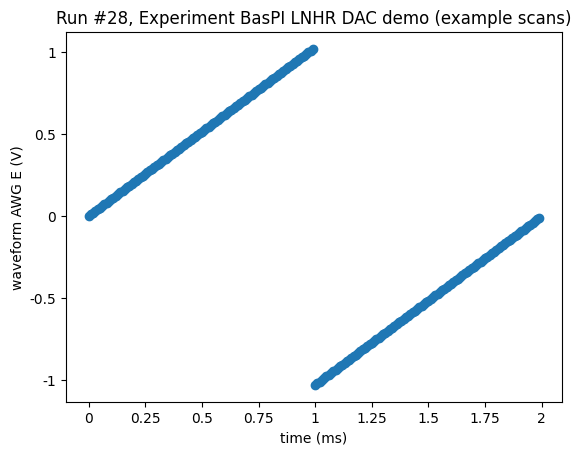

In [29]:
from qcodes.dataset import Measurement, plot_dataset

# set measurement contex
measurement = Measurement()
measurement.register_parameter(DAC.awge.time_axis)
measurement.register_parameter(DAC.awge.waveform, setpoints = (DAC.awge.time_axis,))

# get data from device and save as plottable data
with measurement.run() as datasaver:
    datasaver.add_result((DAC.awge.time_axis, DAC.awge.time_axis.get()), (DAC.awge.waveform, DAC.awge.waveform.get()))
    dataset = datasaver.dataset

plot_dataset(dataset)

## 5 - Using the DAC for 2D-scans

This driver introduces a fast adaptive 2D scan submodule with easy to understand parameters.

But what if a 2D-scan is not time critical? The old fashioned way of using the QCoDeS `do2d` method still works. To decide which method should be used, the following might help decide:
- `do2d`
    - works with most QCoDeS compatible voltage sources
    - is easy to use; coordination between source and measurement device is automatically done by QCoDeS
    - speed of the 2D-scan is restricted by communication speed of the used devices and computing power of the QCoDeS running device, therefore scans are usually slow

- `fast2d`
    - only works with the LNHRDAC IIa
    - is easy to set up; the scan is configured through the `BaspiLnhrdac2Fast2dConfig` class and the trigger parameter
    - speeds of down to 10 &mu;s per point are possible, independent of computing power and communication speeds
    - different external trigger modes are available

### 5.1 - Using the standard QCoDeS `do2d`

As with all past QCoDeS drivers for the LNHRDAC IIa, the `do2d` method still creates a simple 2D-scan. 

The example below uses a dummy instrument for the data acquisition, such that QCoDeS has some data to plot. This must obviously eventually be replaced with a real instrument.

Starting experimental run with id: 29. Using 'qcodes.dataset.do2d'


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

...

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

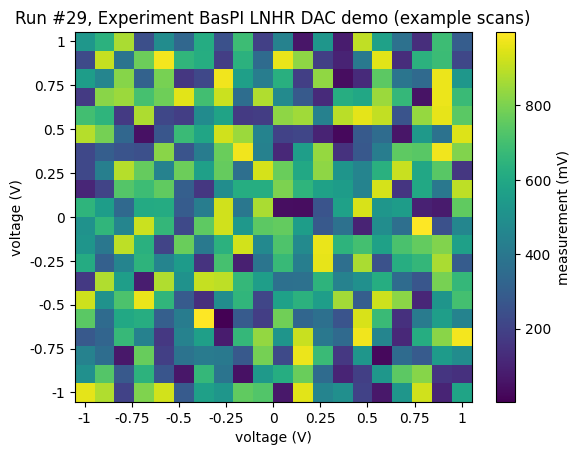

In [30]:
from qcodes.instrument import Instrument, Parameter
from qcodes.utils.dataset.doNd import do2d
import random

# random measurement parameter mimicking a real measurement device
class RandomNumberParameter(Parameter):
    def get_raw(self):
        return random.random()

class RandomNumberInstrument(Instrument):
    def __init__(self, name):
        super().__init__(name)
        self.add_parameter('measurement', parameter_class=RandomNumberParameter, unit='V')

    def get_idn(self):
        return {"vendor": "BasPI", "model": str(self.__class__), "serial": "NA", "firmware": "NA"}

# instantiate the dummy measurement instrument
dummy_instrument = RandomNumberInstrument('random_measurement_instrument')

# select specific channels 
V1 = DAC.ch1.voltage # voltage output channel 1
V2 = DAC.ch2.voltage  # voltage output channel 2

# perform a 2D measurement using the standard QCodDes do2d function
result, _, _ = do2d(
    V1, -1, 1, 20, 0.01,
    V2, -1, 1, 20, 0.01,
    dummy_instrument.measurement,
    do_plot=True,
    show_progress=True
)

### 5.2 - Using the LNHR DAC IIa specific fast adaptive 2D scan `fast2d`

What's new? As the DAC IIa introduces an additional AWG per board and that each AWG has an independent clock, it is now possible to create multiple 2D scans. The `point out` trigger option is now integrated in the back panel, which means that no extra AWG needs to be used as a trigger, which now allows 4 simultaneously running fast adaptive 2d scans. To independantly start a 2D scan, a scan needs to be selected. For that, `scan_unit` can be used.

In a first step, the parameters of a 2D-scan must be defined, in a second step the trigger and DAC outputs must be configured. 

To configure the 2D-scan parameters, an object of class `BaspiLnhrdac2Fast2dConfig` must be created and forwarded to the `fast2d.configuration.set()` parameter. The driver will then automatically configure the DAC correctly in the background. This may take a few seconds.

In [31]:
config_a = BaspiLnhrdac2Fast2dConfig(
        scan_unit= "a",
        x_channel = 1,
        x_start_voltage = 0.0,
        x_stop_voltage = 0.5,
        x_steps = 10,
        y_channel = 2,
        y_start_voltage = 0.0,
        y_stop_voltage = 0.5,
        y_steps = 5,
        acquisition_delay = 0.013,
        adaptive_shift = 0.0
)

DAC.fast2d.configuration.set(config_a)

config_c = BaspiLnhrdac2Fast2dConfig(
        scan_unit= "c",
        x_channel = 13,
        x_start_voltage = 0.0,
        x_stop_voltage = 0.005,
        x_steps = 50,
        y_channel = 14,
        y_start_voltage = 0.0,
        y_stop_voltage = 0.01,
        y_steps = 25,
        acquisition_delay = 0.013,
        adaptive_shift = 0.1
)

DAC.fast2d.configuration.set(config_c)

Starting to configure fast adaptive 2D scan. AWG/STEP-A will be repurposed. AWG/STEP-A cannot be used while the 2D scan is running.
Fast adaptive 2D scan sucessfully configured. Ready to start.
Starting to configure fast adaptive 2D scan. AWG/STEP-C will be repurposed. AWG/STEP-C cannot be used while the 2D scan is running.
Fast adaptive 2D scan sucessfully configured. Ready to start.


After setting the configuration the `fast2d.trigger` parameter can be configured. The LNHRDAC IIa supports four trigger modes:
- `disable`: no trigger is selected, the scan goes as fast as possible, started via software
- `line in`: the LNHRDAC IIa receives a trigger signal, starting each y-axis (fast axis) sweep, whilst the x-axis (slow axis) sweep is done automatically
- `line out`: the LNHRDAC IIa sweeps both axes automatically and sends a trigger signal with every start of a y-axis (fast axis) sweep
- `point out`: the LNHRDAC IIa sweeps both axes automatically and sends a trigger signal with every point of the 2D-scan

Those trigger modes allow for various possible synchronisation methods inbetween the LNHRDAC IIa and the used data aqcusition system.

Finally the outputs must be configured correctly, using the `high_bandwidth`and `enable`parameters of the respective channels. Additionally, setting the output voltages of the chosen outputs to the starting voltage of the 2D-scan might be necessary as well.

In [32]:
from time import sleep

DAC.fast2d.select_scan("a")
DAC.fast2d.trigger.set("point out")

DAC.fast2d.select_scan("c")
DAC.fast2d.trigger.set("disable")

# check status
DAC.fast2d.list_scans()

# Activate channels for Scan A
DAC.ch1.high_bandwidth.set(True)
DAC.ch1.voltage.set(config_a.x_start_voltage)
DAC.ch1.enable.set(True)

DAC.ch2.high_bandwidth.set(True)
DAC.ch2.voltage.set(config_a.y_start_voltage)
DAC.ch2.enable.set(True)

# Activate channels for Scan C
DAC.ch3.high_bandwidth.set(True)
DAC.ch3.voltage.set(config_c.x_start_voltage)
DAC.ch3.enable.set(True)

DAC.ch4.high_bandwidth.set(True)
DAC.ch4.voltage.set(config_c.y_start_voltage)
DAC.ch4.enable.set(True)

DAC.fast2d.start_all()

Selected scan: STEP/AWG-A
Starting to configure fast 2D scan trigger.
Configurating 2D scan trigger mode for a: 'point out'...
Fast 2D scan trigger set to 'point out'.
Selected scan: STEP/AWG-C
Starting to configure fast 2D scan trigger.
Configurating 2D scan trigger mode for c: 'disable'...
Fast 2D scan trigger disabled

=== Configured 2D Scans (2) (current: C) ===

STEP/AWG-A: READY
  X: Ch1 (0.0V -> 0.5V, 10 steps)
  Y: Ch2 (0.0V -> 0.5V, 5 steps)
  Points: 50, Trigger: point out

STEP/AWG-C: READY <- CURRENT
  X: Ch13 (0.0V -> 0.005V, 50 steps)
  Y: Ch14 (0.0V -> 0.01V, 25 steps)
  Points: 1250, Trigger: disable
Selected scan: STEP/AWG-A
Fast adaptive 2D scan A started with configuration BaspiLnhrdac2Fast2dConfig(scan_unit='a', x_channel=1, x_start_voltage=0.0, x_stop_voltage=0.5, x_steps=10, y_channel=2, y_start_voltage=0.0, y_stop_voltage=0.5, y_steps=5, acquisition_delay=0.013, adaptive_shift=0.0)
Selected scan: STEP/AWG-C
Fast adaptive 2D scan C started with configuration Baspi

The `fast2d` submodule has no implemented plotting funtion. The collected data from a 2D-scan must therefore be manually plotted by the user. The voltages outputted by the LNHRDAC II can be read out with the `fast2d.x_axis.get()` and `fast2d.y_axis.get()` parameters.

In [33]:
DAC.fast2d.select_scan("a")
x_axis = DAC.fast2d.x_axis.get()
y_axis = DAC.fast2d.y_axis.get()

print(f"Y-axis values are:")
print(y_axis)
print(f"X-axis values are:")
print(x_axis)

Selected scan: STEP/AWG-A
Y-axis values are:
[0.  0.1 0.2 0.3 0.4 0.5]
X-axis values are:
[0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5 ]


## 6 – Reconnecting to the LNHR DAC II `reconnect`

In situations where the software loses connection to the LNHR DAC IIa, for example: Telnet timeout, VISA socket interruption, or a restart of the Telnet server, the device may still be powered on and operating normally.
To restore communication without modifying any DAC settings, the reconnect() method can be used.

The `reconnect` function performs:

- an automatic closure of any previously opened VISA/Telnet session

- the re-opening of a new connection

- the verification of communication by reading the device identification (get_idn())

- optional retry attempts with delays between attempts

This method does not restore state after a full power cycle of the instrument.
For a device restart, the driver must be fully re-initialized.

### 6.1 Reconnect Procedure

Calling `reconnect()` will:

1. close any existing VISA socket (if it still exists)

2. attempt to open a new VISA/Telnet connection

3. restore line terminations (\r\n)

4. verify communication by reading the IDN string

5. repeat the process if communication fails

6. raise a descriptive error after all attempts fail

The default reconnect behaviour uses:

- 10 attempts

- 5 seconds wait between attempts

Both can be customized.

### 6.2 Example: Using reconnect() after a Telnet Restart

Before calling `reconnect()`, ensure that the LNHR DAC II Telnet server has been restarted using the rotary knob on the LNHR DAC II:

`Main Menu` -> scroll down to `Restart the device` -> `Restart Telnet now!`

In [1]:
from time import sleep

# to simulate a connection loss, remove the ethernet cable from your notebook and replug it
# the device has have to be initialised before

DAC.ch1.voltage.set(5.86)
DAC.ch1.enable.set(True)
print("Voltage before connection loss from CH1:", DAC.ch1.voltage.get(), "V")

print("Simulating connection loss... disconnect your ethernet cable now")
sleep(5)

print("Please now restart the Telnet server on the device.")
sleep(3)

print("Plug in your ethernet cable now.")
print("Attempting to reconnect...")

try:
    DAC.reconnect(
        attempts=5,              # number of reconnect attempts
        wait_between_attempts=2.0 # delay between attempts in seconds
    )
    print("Reconnect completed successfully.")

except Exception as e:
    print("Reconnect failed:")
    print(e)


print("Voltage from CH1 after reconnecting:", DAC.ch1.voltage.get(), "V")

DAC.ch1.voltage.set(-3.45)
print("Changed voltage from CH1 after reconnecting:", DAC.ch1.voltage.get(), "V")


NameError: name 'DAC' is not defined